## 🛍️ Gender_Data_Understanding

> 백화점 거래 데이터(2017–2018) 기반 **고객 성별 (0=여, 1=남) 이진 분류** 문제의 기본 EDA.
> 교수님 baseline(`starter_code.ipynb`)의 `make_customer_features`를 그대로 채택하여
> 거래 단위 raw 데이터와 baseline feature 단위 두 층위를 함께 이해한다.
___

### 📑 목차
***1. DataSet Overview***  
***2. Baseline Customer Feature 구축***  
***3. Feature Group Overview (baseline 78 feature)***  
***4. Cardinality Analysis***  
***5. Missing Value Analysis***  
***6. 환불·이상치(음수 거래) Overview***  
***7. Summary***

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, HTML

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 200)
plt.rcParams['axes.unicode_minus'] = False

import platform
system_name = platform.system()
if system_name == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif system_name == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')

In [5]:
train_tx = pd.read_csv('../data/raw/train_transactions.csv', encoding='cp949')
test_tx  = pd.read_csv('../data/raw/test_transactions.csv',  encoding='cp949')
y_train  = pd.read_csv('../data/raw/y_train.csv',            encoding='cp949')

train_tx['sales_datetime'] = pd.to_datetime(train_tx['sales_datetime'])
test_tx['sales_datetime']  = pd.to_datetime(test_tx['sales_datetime'])

print('train_tx:', train_tx.shape, ' | test_tx:', test_tx.shape, ' | y_train:', y_train.shape)
print('train 기간:', train_tx['sales_datetime'].min(), '~', train_tx['sales_datetime'].max())
print('test  기간:', test_tx['sales_datetime'].min(),  '~', test_tx['sales_datetime'].max())
print('train 고객:', train_tx['custid'].nunique(), ' | test 고객:', test_tx['custid'].nunique())

train_tx: (1036653, 16)  | test_tx: (689777, 16)  | y_train: (30000, 2)
train 기간: 2017-05-01 09:20:00 ~ 2018-04-29 20:00:00
test  기간: 2017-05-01 09:40:00 ~ 2018-04-29 20:03:00
train 고객: 30000  | test 고객: 19995


### ***1. DataSet Overview***

>train_transactions.csv: 1,036,653 거래 × 16 컬럼  
>test_transactions.csv : 689,777 거래 × 16 컬럼  
>y_train.csv: 30,000 고객 × (custid, **gender**) — `0=여성`, `1=남성`
```
  custid: 고객 식별자 (예측·집계의 기본 키)
  sales_datetime: 거래 일시
  str_nm: 점포명
  goodcd: 상품 코드 (high cardinality)
  brd_nm: 브랜드명
  corner_nm / pc_nm / part_nm / team_nm / buyer_nm: 상품 카테고리 계층 (코너명 / 상품군 / 파트 / 팀 / 바이어)
  import_flg: 수입 상품 여부 (0/1)
  tot_amt: 총 거래 금액 (환불 시 음수)
  dis_amt: 할인 금액
  net_amt: 실 매출 (실 결제금액) [tot_amt - dis_amt)]
  inst_mon: 할부 개월
  inst_fee: 할부 수수료
  [gender: 0/1 ~ Label(0은 여자, 1은 남자), custid 단위]
``` 
**예측 단위**는 거래(row)가 아닌 **고객(custid)** — 모든 EDA는 (1) 거래 raw, (2) 교수님 baseline feature 두 층위로 살핀다.

In [7]:
train_tx.head()

,custid,sales_datetime,str_nm,goodcd,brd_nm,corner_nm,pc_nm,part_nm,team_nm,buyer_nm,import_flg,tot_amt,dis_amt,net_amt,inst_mon,inst_fee
0,0,2017-06-25 12:12:00,무역점,2116050008000,에스티로더,수입종합화장품,화장품,명품잡화,잡화가용팀,화장품,1,90000,9000,81000,3,0
1,0,2017-06-25 12:42:00,무역점,4125440008000,시슬리,수입종합화장품,화장품,명품잡화,잡화가용팀,화장품,1,39000,3900,35100,1,0
2,0,2017-08-26 18:10:00,본점,2116052008000,크리니크,수입종합화장품,화장품,잡화파트,잡화가용팀,화장품,1,175000,17500,157500,3,0
3,0,2017-08-26 18:30:00,본점,4106430119900,듀퐁,수입의류,명품토탈,잡화파트,잡화가용팀,수입명품,1,455000,45500,409500,3,0
4,0,2017-09-03 18:02:00,무역점,2139141008000,랑콤,수입종합화장품,화장품,명품잡화,잡화가용팀,화장품,0,100000,10000,90000,3,0


In [8]:
train_tx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036653 entries, 0 to 1036652
Data columns (total 16 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   custid          1036653 non-null  int64         
 1   sales_datetime  1036653 non-null  datetime64[ns]
 2   str_nm          1036653 non-null  object        
 3   goodcd          1036653 non-null  int64         
 4   brd_nm          1036653 non-null  object        
 5   corner_nm       1036653 non-null  object        
 6   pc_nm           1036653 non-null  object        
 7   part_nm         1036653 non-null  object        
 8   team_nm         1036653 non-null  object        
 9   buyer_nm        1036653 non-null  object        
 10  import_flg      1036653 non-null  int64         
 11  tot_amt         1036653 non-null  int64         
 12  dis_amt         1036653 non-null  int64         
 13  net_amt         1036653 non-null  int64         
 14  inst_mon        10

In [9]:
y_train['gender'].value_counts().to_frame('count').assign(
    ratio=lambda d: d['count']/d['count'].sum()
).rename(index={0:'0 (여)', 1:'1 (남)'})

,count,ratio
gender,,
0 (여),20882,0.696067
1 (남),9118,0.303933


### ***2. Baseline Customer Feature 구축***

> 교수님 starter의 `make_customer_features`를 그대로 사용한다.
> 이 함수는 거래 데이터를 고객 단위로 변환하며, 총 **78개 base feature**를 생성한다.
>
> **구성 (6 그룹)**
> 1. **기본 구매량/다양성**: `total_txn_cnt`, `unique_*`(goods/brand/corner/pc/part/team/store), `visit_days`, `goods_diversity`, `brand_diversity`, `txn_per_visit`
> 2. **금액**: `total_net`, `mean_net`, `max_net`, `min_net`, `std_net`, `median_net`, `total_tot`, `total_dis`, `discount_rate`, `amt_per_visit`
> 3. **행동 비율**: `refund_ratio`, `import_ratio`, `installment_ratio`, `mean_inst_mon`, `weekend_ratio`
> 4. **카테고리 비중**: `ratio_team_*`, `ratio_part_*`
> 5. **시점/공간 비중**: `ratio_season_*`, `ratio_time_*`, `ratio_store_*`
> 6. **집중도**: `max_team_ratio`, `max_part_ratio`, `max_season_ratio`

In [11]:
def make_customer_features(df):
    """교수님 baseline starter_code의 make_customer_features 동일 로직."""
    df = df.copy()
    df['sales_datetime'] = pd.to_datetime(df['sales_datetime'])
    df['sales_day'] = df['sales_datetime'].dt.normalize()
    df['month']   = df['sales_datetime'].dt.month
    df['weekday'] = df['sales_datetime'].dt.weekday
    df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)
    season_map = {3:'봄',4:'봄',5:'봄',6:'여름',7:'여름',8:'여름',
                  9:'가을',10:'가을',11:'가을',12:'겨울',1:'겨울',2:'겨울'}
    df['season'] = df['month'].map(season_map)
    df['hour']  = df['sales_datetime'].dt.hour
    df['time_zone'] = pd.cut(df['hour'], bins=[-1,11,14,17,24],
                             labels=['오전','점심','오후','저녁'])
    df['is_refund']     = (df['net_amt']<0).astype(int)
    df['is_installment']= (df['inst_mon']>1).astype(int)

    g = df.groupby('custid')
    base = g.agg(
        total_txn_cnt=('goodcd','size'),
        unique_goods =('goodcd','nunique'),
        unique_brand =('brd_nm','nunique'),
        unique_corner=('corner_nm','nunique'),
        unique_pc    =('pc_nm','nunique'),
        unique_part  =('part_nm','nunique'),
        unique_team  =('team_nm','nunique'),
        unique_store =('str_nm','nunique'),
        visit_days   =('sales_day','nunique'),
    )
    base['goods_diversity'] = base['unique_goods']/base['total_txn_cnt']
    base['brand_diversity'] = base['unique_brand']/base['total_txn_cnt']
    base['txn_per_visit']   = base['total_txn_cnt']/base['visit_days']

    amt = g.agg(
        total_net =('net_amt','sum'),
        mean_net  =('net_amt','mean'),
        max_net   =('net_amt','max'),
        min_net   =('net_amt','min'),
        std_net   =('net_amt','std'),
        median_net=('net_amt','median'),
        total_tot =('tot_amt','sum'),
        total_dis =('dis_amt','sum'),
    )
    amt['discount_rate'] = amt['total_dis']/(amt['total_tot'].abs()+1)
    amt['amt_per_visit'] = amt['total_net']/base['visit_days']

    behavior = g.agg(
        refund_ratio     =('is_refund','mean'),
        import_ratio     =('import_flg','mean'),
        installment_ratio=('is_installment','mean'),
        mean_inst_mon    =('inst_mon','mean'),
        weekend_ratio    =('is_weekend','mean'),
    )

    team_ratio   = pd.crosstab(df['custid'], df['team_nm'],  normalize='index').add_prefix('ratio_team_')
    part_ratio   = pd.crosstab(df['custid'], df['part_nm'],  normalize='index').add_prefix('ratio_part_')
    season_ratio = pd.crosstab(df['custid'], df['season'],   normalize='index').add_prefix('ratio_season_')
    time_ratio   = pd.crosstab(df['custid'], df['time_zone'],normalize='index').add_prefix('ratio_time_')
    store_ratio  = pd.crosstab(df['custid'], df['str_nm'],   normalize='index').add_prefix('ratio_store_')

    conc = pd.DataFrame(index=base.index)
    conc['max_team_ratio']   = team_ratio.max(axis=1)
    conc['max_part_ratio']   = part_ratio.max(axis=1)
    conc['max_season_ratio'] = season_ratio.max(axis=1)

    feats = pd.concat([base, amt, behavior, team_ratio, part_ratio,
                       season_ratio, time_ratio, store_ratio, conc], axis=1)
    return feats.fillna(0).reset_index()

In [12]:
cust_train = make_customer_features(train_tx).merge(y_train, on='custid', how='left')
cust_test  = make_customer_features(test_tx)

print('cust_train:', cust_train.shape, ' | cust_test:', cust_test.shape)
cust_train.head()

cust_train: (30000, 80)  | cust_test: (19995, 77)


,custid,total_txn_cnt,unique_goods,unique_brand,unique_corner,unique_pc,unique_part,unique_team,unique_store,visit_days,goods_diversity,brand_diversity,txn_per_visit,total_net,mean_net,max_net,min_net,std_net,median_net,total_tot,total_dis,discount_rate,amt_per_visit,refund_ratio,import_ratio,installment_ratio,mean_inst_mon,weekend_ratio,ratio_team_상품개발영업2과,ratio_team_식품팀,ratio_team_의류패션팀,ratio_team_인터넷백화점,ratio_team_잡화가용팀,ratio_part_가정용품,ratio_part_가정용품파트,ratio_part_골프/유니캐쥬얼,ratio_part_공산품,ratio_part_공산품파트,ratio_part_남성의류,ratio_part_남성정장스포츠,ratio_part_로얄부띠끄,ratio_part_로얄부틱,ratio_part_명품잡화,ratio_part_상품개발영업1과,ratio_part_생식품,ratio_part_생식품파트,ratio_part_스포츠캐주얼,ratio_part_스포츠캐쥬얼,ratio_part_아동,"ratio_part_아동,스포츠",ratio_part_아동문화,ratio_part_여성의류파트,ratio_part_여성정장,ratio_part_여성캐주얼,ratio_part_여성캐쥬얼,ratio_part_영라이브,ratio_part_영어덜트캐쥬얼,ratio_part_영캐릭터,ratio_part_영플라자,ratio_part_인터넷백화점,ratio_part_잡화,ratio_part_잡화파트,"ratio_part_케주얼,구두,아동",ratio_part_패션잡화,ratio_season_가을,ratio_season_겨울,ratio_season_봄,ratio_season_여름,ratio_time_오전,ratio_time_점심,ratio_time_오후,ratio_time_저녁,ratio_store_무역점,ratio_store_본점,ratio_store_신촌점,ratio_store_천호점,max_team_ratio,max_part_ratio,max_season_ratio,gender
0,0,11,7,7,4,4,4,2,2,7,0.636364,0.636364,1.571429,1567800,142527.272727,409500,35100,106686.466723,101700.0,1742000,174200,0.100000,223971.428571,0.000000,0.636364,0.909091,2.818182,0.636364,0.0,0.0,0.181818,0.0,0.818182,0.000000,0.000000,0.090909,0.0,0.0,0.090909,0.000000,0.000000,0.0,0.272727,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.00,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.545455,0.000000,0.0,0.272727,0.272727,0.090909,0.363636,0.000000,0.181818,0.000000,0.818182,0.454545,0.545455,0.0,0.000000,0.818182,0.545455,0.363636,1
1,1,26,22,19,16,13,8,2,2,16,0.846154,0.730769,1.625000,2715470,104441.153846,373350,-69350,106626.699258,68975.0,2772100,56630,0.020429,169716.875000,0.076923,0.423077,0.730769,2.461538,0.500000,0.0,0.0,0.692308,0.0,0.307692,0.038462,0.038462,0.000000,0.0,0.0,0.000000,0.038462,0.230769,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.038462,0.00,0.115385,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.192308,0.307692,0.0,0.230769,0.038462,0.384615,0.346154,0.153846,0.153846,0.500000,0.192308,0.153846,0.846154,0.0,0.000000,0.692308,0.307692,0.384615,1
2,2,11,7,7,7,7,6,2,2,7,0.636364,0.636364,1.571429,3495760,317796.363636,1416000,-1416000,776954.884498,364050.0,3750850,255090,0.068009,499394.285714,0.181818,0.090909,0.545455,3.454545,0.363636,0.0,0.0,0.454545,0.0,0.545455,0.363636,0.000000,0.272727,0.0,0.0,0.090909,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.090909,0.0,0.0,0.000000,0.00,0.000000,0.0,0.000000,0.090909,0.0,0.0,0.0,0.090909,0.000000,0.000000,0.0,0.454545,0.272727,0.000000,0.272727,0.272727,0.181818,0.181818,0.363636,0.727273,0.000000,0.0,0.272727,0.545455,0.363636,0.454545,1
3,3,30,22,21,18,14,8,3,2,13,0.733333,0.700000,2.307692,2208840,73628.000000,589950,-589950,182338.245679,62800.0,2300500,91660,0.039843,169910.769231,0.066667,0.000000,0.733333,2.666667,0.366667,0.0,0.1,0.433333,0.0,0.466667,0.066667,0.000000,0.000000,0.1,0.0,0.100000,0.000000,0.000000,0.0,0.066667,0.0,0.0,0.0,0.0,0.3,0.033333,0.0,0.0,0.000000,0.00,0.000000,0.0,0.233333,0.100000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.100000,0.200000,0.300000,0.400000,0.100000,0.266667,0.200000,0.433333,0.133333,0.000000,0.0,0.866667,0.466667,0.300000,0.400000,0
4,4,4,4,4,4,3,3,2,1,2,1.000000,1.000000,2.000000,1023200,255800.000000,560000,49000,248399.731616,207100.0,1045000,21800,0.020861,511600.000000,0.000000,0.250000,0.750000,4.500000,0.250000,0.0,0.0,0.750000,0.0,0.250000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.250000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.25,0.500000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.000000,0.750000,0.500000,1.000000,0


In [45]:
cust_test.head()

,custid,total_txn_cnt,unique_goods,unique_brand,unique_corner,unique_pc,unique_part,unique_team,unique_store,visit_days,goods_diversity,brand_diversity,txn_per_visit,total_net,mean_net,max_net,min_net,std_net,median_net,total_tot,total_dis,discount_rate,amt_per_visit,refund_ratio,import_ratio,installment_ratio,mean_inst_mon,weekend_ratio,ratio_team_상품개발영업2과,ratio_team_식품팀,ratio_team_의류패션팀,ratio_team_잡화가용팀,ratio_part_가정용품,ratio_part_가정용품파트,ratio_part_골프/유니캐쥬얼,ratio_part_공산품,ratio_part_공산품파트,ratio_part_남성의류,ratio_part_남성정장스포츠,ratio_part_로얄부띠끄,ratio_part_로얄부틱,ratio_part_명품잡화,ratio_part_상품개발영업1과,ratio_part_생식품,ratio_part_생식품파트,ratio_part_스포츠캐주얼,ratio_part_스포츠캐쥬얼,ratio_part_아동,"ratio_part_아동,스포츠",ratio_part_아동문화,ratio_part_여성의류파트,ratio_part_여성정장,ratio_part_여성캐주얼,ratio_part_여성캐쥬얼,ratio_part_영라이브,ratio_part_영어덜트캐쥬얼,ratio_part_영캐릭터,ratio_part_영플라자,ratio_part_잡화,ratio_part_잡화파트,"ratio_part_케주얼,구두,아동",ratio_part_패션잡화,ratio_season_가을,ratio_season_겨울,ratio_season_봄,ratio_season_여름,ratio_time_오전,ratio_time_점심,ratio_time_오후,ratio_time_저녁,ratio_store_무역점,ratio_store_본점,ratio_store_신촌점,ratio_store_천호점,max_team_ratio,max_part_ratio,max_season_ratio
0,30000,27,16,16,18,15,8,3,2,15,0.592593,0.592593,1.800000,2000460,74091.111111,425600,-150100,105310.652516,44650.0,2078240,77780,0.037426,133364.000000,0.037037,0.074074,0.111111,1.222222,0.555556,0.0,0.296296,0.370370,0.333333,0.000000,0.111111,0.074074,0.000000,0.296296,0.037037,0.074074,0.0,0.0,0.037037,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.00,0.0,0.0,0.0,0.000000,0.000000,0.0,0.111111,0.259259,0.000000,0.148148,0.333333,0.333333,0.185185,0.037037,0.000000,0.407407,0.555556,0.148148,0.851852,0.0,0.0,0.370370,0.296296,0.333333
1,30001,27,20,19,17,13,10,3,2,10,0.740741,0.703704,2.700000,4040250,149638.888889,771400,-61460,169108.837902,95600.0,4158320,118070,0.028394,404025.000000,0.037037,0.074074,0.370370,1.740741,0.740741,0.0,0.148148,0.370370,0.481481,0.000000,0.037037,0.000000,0.037037,0.074074,0.000000,0.296296,0.0,0.0,0.037037,0.0,0.000000,0.037037,0.000000,0.0,0.0,0.037037,0.000000,0.037037,0.0,0.00,0.0,0.0,0.0,0.000000,0.000000,0.0,0.074074,0.333333,0.000000,0.111111,0.222222,0.333333,0.333333,0.000000,0.000000,0.703704,0.296296,0.111111,0.888889,0.0,0.0,0.481481,0.333333,0.333333
2,30002,100,48,42,25,19,13,3,2,29,0.480000,0.420000,3.448276,7692206,76922.060000,389500,-389500,101831.937558,66500.0,8007256,315050,0.039346,265248.482759,0.080000,0.250000,0.540000,2.080000,0.300000,0.0,0.040000,0.480000,0.480000,0.070000,0.040000,0.210000,0.030000,0.000000,0.000000,0.010000,0.0,0.0,0.110000,0.0,0.000000,0.010000,0.000000,0.0,0.0,0.090000,0.000000,0.030000,0.0,0.09,0.0,0.0,0.0,0.000000,0.000000,0.0,0.150000,0.150000,0.010000,0.270000,0.220000,0.250000,0.260000,0.130000,0.390000,0.360000,0.120000,0.610000,0.390000,0.0,0.0,0.480000,0.210000,0.270000
3,30003,43,28,28,25,16,8,3,1,25,0.651163,0.651163,1.720000,1348730,31365.813953,138000,-138000,48886.470581,19000.0,1367820,19090,0.013957,53949.200000,0.093023,0.116279,0.186047,1.372093,0.186047,0.0,0.139535,0.441860,0.418605,0.023256,0.000000,0.000000,0.116279,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.023256,0.000000,0.046512,0.0,0.0,0.000000,0.116279,0.000000,0.0,0.00,0.0,0.0,0.0,0.209302,0.232558,0.0,0.000000,0.000000,0.232558,0.465116,0.162791,0.232558,0.139535,0.000000,0.395349,0.255814,0.348837,0.000000,0.000000,1.0,0.0,0.441860,0.232558,0.465116
4,30004,55,26,23,23,15,6,3,2,32,0.472727,0.418182,1.718750,2883691,52430.745455,1110000,-35000,151861.837533,21000.0,2890471,6780,0.002346,90115.343750,0.072727,0.072727,0.163636,1.327273,0.254545,0.0,0.290909,0.272727,0.436364,0.000000,0.309091,0.000000,0.018182,0.145455,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.127273,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.00,0.0,0.0,0.0,0.000000,0.000000,0.0,0.127273,0.272727,0.000000,0.381818,0.163636,0.036364,0.418182,0.054545,0.181818,0.363636,0.400000,0.018182,0.981818,0.0,0.0,0.436364,0.309091,0.4

In [49]:
cols1 = set(cust_train.columns)
cols2 = set(cust_test.columns)

print(cols1 - cols2) # cust_train에만 있는 컬럼
print(cols2 - cols1) # cust_test에만 있는 컬럼

{'gender', 'ratio_part_인터넷백화점', 'ratio_team_인터넷백화점'}
set()


In [13]:
# 6개 그룹별 컬럼 분류
base_cols   = ['total_txn_cnt','unique_goods','unique_brand','unique_corner','unique_pc',
               'unique_part','unique_team','unique_store','visit_days',
               'goods_diversity','brand_diversity','txn_per_visit']
amt_cols    = ['total_net','mean_net','max_net','min_net','std_net','median_net',
               'total_tot','total_dis','discount_rate','amt_per_visit']
beh_cols    = ['refund_ratio','import_ratio','installment_ratio','mean_inst_mon','weekend_ratio']
team_cols   = [c for c in cust_train.columns if c.startswith('ratio_team_')]
part_cols   = [c for c in cust_train.columns if c.startswith('ratio_part_')]
season_cols = [c for c in cust_train.columns if c.startswith('ratio_season_')]
time_cols   = [c for c in cust_train.columns if c.startswith('ratio_time_')]
store_cols  = [c for c in cust_train.columns if c.startswith('ratio_store_')]
conc_cols   = ['max_team_ratio','max_part_ratio','max_season_ratio']

groups = {
    '기본/다양성': base_cols, '금액': amt_cols, '행동 비율': beh_cols,
    'team 비중': team_cols, 'part 비중': part_cols,
    'season 비중': season_cols, 'time 비중': time_cols, 'store 비중': store_cols,
    '집중도': conc_cols,
}
for k,v in groups.items():
    print(f'{k:12s} | {len(v):>3} cols')

기본/다양성       |  12 cols
금액           |  10 cols
행동 비율        |   5 cols
team 비중      |   5 cols
part 비중      |  31 cols
season 비중    |   4 cols
time 비중      |   4 cols
store 비중     |   4 cols
집중도          |   3 cols


### ***3. Feature Group Overview (baseline 78 feature)***

> baseline feature 각 그룹의 dtype·결측·cardinality·샘플값을 확인한다.

In [15]:
with pd.option_context('display.max_columns', None):
    for gname, cols in groups.items():
        if not cols: continue
        meta = pd.DataFrame(
            [
                cust_train[cols].isna().sum(),
                cust_train[cols].nunique(dropna=True),
            ],
            index=['Missing','Unique']
        ).astype(int)
        sample = cust_train[cols].head(3).round(4)
        display(Markdown(f"### 📌 **{gname} ({len(cols)} cols)**"))
        display(pd.concat([meta, sample]))
        display(HTML("<hr>"))

### 📌 **기본/다양성 (12 cols)**

,total_txn_cnt,unique_goods,unique_brand,unique_corner,unique_pc,unique_part,unique_team,unique_store,visit_days,goods_diversity,brand_diversity,txn_per_visit
Missing,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000
Unique,324,140,121,76,46,25,4,4,170,2760.0000,2636.0000,2488.0000
0,11,7,7,4,4,4,2,2,7,0.6364,0.6364,1.5714
1,26,22,19,16,13,8,2,2,16,0.8462,0.7308,1.6250
2,11,7,7,7,7,6,2,2,7,0.6364,0.6364,1.5714


### 📌 **금액 (10 cols)**

,total_net,mean_net,max_net,min_net,std_net,median_net,total_tot,total_dis,discount_rate,amt_per_visit
Missing,0,0.0000,0,0,0.0000,0.0,0,0,0.0000,0.0000
Unique,28125,28588.0000,6701,7048,29035.0000,9721.0,26010,14404,28807.0000,28520.0000
0,1567800,142527.2727,409500,35100,106686.4667,101700.0,1742000,174200,0.1000,223971.4286
1,2715470,104441.1538,373350,-69350,106626.6993,68975.0,2772100,56630,0.0204,169716.8750
2,3495760,317796.3636,1416000,-1416000,776954.8845,364050.0,3750850,255090,0.0680,499394.2857


### 📌 **행동 비율 (5 cols)**

...

,ratio_time_오전,ratio_time_점심,ratio_time_오후,ratio_time_저녁
Missing,0.0000,0.0000,0.0000,0.0000
Unique,1955.0000,2817.0000,2812.0000,2739.0000
0,0.0000,0.1818,0.0000,0.8182
1,0.1538,0.1538,0.5000,0.1923
2,0.2727,0.1818,0.1818,0.3636


### 📌 **store 비중 (4 cols)**

,ratio_store_무역점,ratio_store_본점,ratio_store_신촌점,ratio_store_천호점
Missing,0.0000,0.0000,0.0,0.0000
Unique,2209.0000,2142.0000,1335.0,1323.0000
0,0.4545,0.5455,0.0,0.0000
1,0.1538,0.8462,0.0,0.0000
2,0.7273,0.0000,0.0,0.2727


### 📌 **집중도 (3 cols)**

,max_team_ratio,max_part_ratio,max_season_ratio
Missing,0.0000,0.0000,0.0000
Unique,2378.0000,2343.0000,1924.0000
0,0.8182,0.5455,0.3636
1,0.6923,0.3077,0.3846
2,0.5455,0.3636,0.4545


### ***4. Cardinality Analysis***

> 거래 raw + baseline feature 두 층위를 함께 본다.

In [17]:
# (1) 거래 단위 raw
card_tx = train_tx.nunique(dropna=True).sort_values(ascending=False).to_frame('cardinality')
card_tx['dtype'] = train_tx.dtypes.astype(str)
display(Markdown('#### 거래 단위 raw cardinality'))
display(card_tx)

hier = ['team_nm','part_nm','pc_nm','corner_nm','buyer_nm','brd_nm','goodcd']
display(Markdown('#### 카테고리 계층 cardinality 흐름'))
display(pd.Series({c: train_tx[c].nunique() for c in hier}, name='unique').to_frame())

#### 거래 단위 raw cardinality

,cardinality,dtype
net_amt,95512,int64
tot_amt,88094,int64
sales_datetime,72591,datetime64[ns]
custid,30000,int64
goodcd,10427,int64
dis_amt,8314,int64
brd_nm,1882,object
corner_nm,309,object
pc_nm,78,object
buyer_nm,35,object


#### 카테고리 계층 cardinality 흐름

,unique
team_nm,5
part_nm,31
pc_nm,78
corner_nm,309
buyer_nm,35
brd_nm,1882
goodcd,10427


In [18]:
# (2) baseline feature cardinality 상/하위
high = cust_train.drop(columns=['custid','gender']).nunique().sort_values(ascending=False).head(20).reset_index()
high.columns = ['high_col','high_card']
low  = cust_train.drop(columns=['custid','gender']).nunique().sort_values(ascending=True).head(20).reset_index()
low.columns  = ['low_col','low_card']
display(pd.concat([high, low], axis=1))

,high_col,high_card,low_col,low_card
0,std_net,29035,ratio_team_상품개발영업2과,2
1,discount_rate,28807,ratio_part_상품개발영업1과,2
2,mean_net,28588,ratio_part_인터넷백화점,2
3,amt_per_visit,28520,ratio_team_인터넷백화점,2
4,total_net,28125,unique_team,4
5,total_tot,26010,unique_store,4
6,total_dis,14404,unique_part,25
7,median_net,9721,unique_pc,46
8,min_net,7048,unique_corner,76
9,max_net,6701,unique_brand,121


### ***5. Missing Value Analysis***

> raw 데이터엔 결측이 없는 것으로 보이고, baseline feature는 fillna(0) 처리되어 있다.
> 다만 `std_net`처럼 거래가 1건이면 NaN→0 채워진 것이 분포에 영향 줄 수 있으므로 확인한다.

In [20]:
miss_tx = pd.DataFrame({
    'dtype': train_tx.dtypes,
    'missing_count': train_tx.isna().sum(),
    'missing_ratio': train_tx.isna().mean(),
}).sort_values('missing_count', ascending=False)
display(Markdown('#### 거래 raw 결측'))
display(miss_tx)

# fillna(0) 영향이 큰 feature 후보 - 거래 1건 고객 수
n_single = (cust_train['total_txn_cnt']==1).sum()
print(f'\n거래 1건 고객 수: {n_single:,} ({n_single/len(cust_train):.3%})')
print('  → 이 고객들은 std_net이 NaN이었으나 0으로 채워짐. 분포 해석 시 유의.')

#### 거래 raw 결측

,dtype,missing_count,missing_ratio
custid,int64,0,0.0
sales_datetime,datetime64[ns],0,0.0
str_nm,object,0,0.0
goodcd,int64,0,0.0
brd_nm,object,0,0.0
corner_nm,object,0,0.0
pc_nm,object,0,0.0
part_nm,object,0,0.0
team_nm,object,0,0.0
buyer_nm,object,0,0.0



거래 1건 고객 수: 675 (2.250%)
  → 이 고객들은 std_net이 NaN이었으나 0으로 채워짐. 분포 해석 시 유의.


### ***6. 환불·이상치(음수 거래) Overview***

> 백화점 데이터 특성상 환불(음수 `tot_amt`)이 존재한다.
> baseline에는 `refund_ratio`로 반영되어 있는데, 이게 raw에서 어느 정도 비중인지 확인한다.

음수 거래(환불) 비율: 0.0668  (69,199 / 1,036,653)
tot_amt == 0 비율 : 0.0000
net_amt <= 0 비율 : 0.0668


,tot_amt
count,1.036653e+06
mean,9.845307e+04
std,3.205360e+05
min,-7.200000e+07
1%,-3.698480e+05
5%,-5.400000e+04
50%,5.200000e+04
95%,3.970000e+05
99%,1.032000e+06
max,7.200000e+07


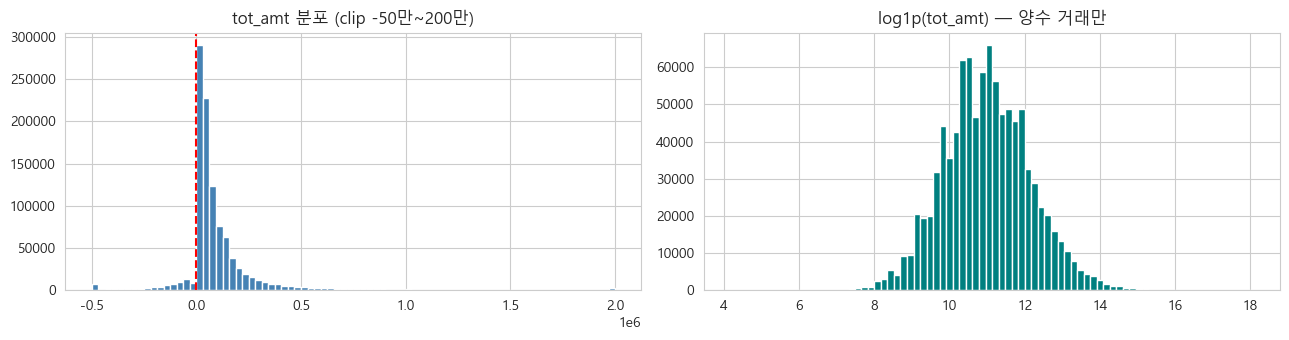

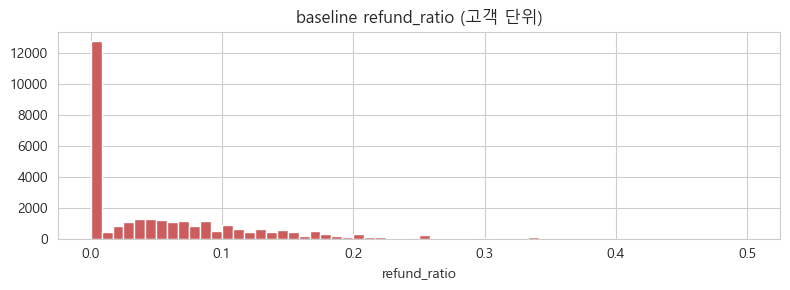

In [22]:
neg = train_tx['tot_amt'] < 0
print(f'음수 거래(환불) 비율: {neg.mean():.4f}  ({neg.sum():,} / {len(train_tx):,})')
print(f'tot_amt == 0 비율 : {(train_tx["tot_amt"]==0).mean():.4f}')
print(f'net_amt <= 0 비율 : {(train_tx["net_amt"]<=0).mean():.4f}')
display(train_tx['tot_amt'].describe(percentiles=[.01,.05,.5,.95,.99]).to_frame())

fig, axes = plt.subplots(1,2, figsize=(13,3.5))
axes[0].hist(np.clip(train_tx['tot_amt'], -500000, 2000000), bins=80, color='steelblue')
axes[0].axvline(0, color='red', ls='--'); axes[0].set_title('tot_amt 분포 (clip -50만~200만)')
axes[1].hist(np.log1p(train_tx.loc[train_tx['tot_amt']>0,'tot_amt']), bins=80, color='teal')
axes[1].set_title('log1p(tot_amt) — 양수 거래만')
plt.tight_layout(); plt.show()

# baseline의 refund_ratio 분포
plt.figure(figsize=(8,3))
plt.hist(cust_train['refund_ratio'], bins=60, color='indianred')
plt.title('baseline refund_ratio (고객 단위)'); plt.xlabel('refund_ratio'); plt.tight_layout(); plt.show()

### ***7. Summary***

In [24]:
rows = []
for name, df in [('train_tx', train_tx), ('test_tx', test_tx)]:
    rows.append({
        'dataset': name,
        'n_rows': len(df),
        'n_custid': df['custid'].nunique(),
        'period_start': df['sales_datetime'].min(),
        'period_end'  : df['sales_datetime'].max(),
        'neg_tx_ratio': float((df['tot_amt']<0).mean()),
    })
display(pd.DataFrame(rows))

print('\n[Baseline feature 그룹별 컬럼 수]')
for k,v in groups.items():
    print(f'  {k:12s} | {len(v):>3} cols')
print(f'\n총 baseline feature 수: {sum(len(v) for v in groups.values())}')
print(f'(custid, gender 제외)')

print('\n[고객 단위 라벨 분포]')
display(cust_train['gender'].value_counts().to_frame('count').assign(
    ratio=lambda d: d['count']/d['count'].sum()
).rename(index={0:'0 (여)', 1:'1 (남)'}))

,dataset,n_rows,n_custid,period_start,period_end,neg_tx_ratio
0,train_tx,1036653,30000,2017-05-01 09:20:00,2018-04-29 20:00:00,0.066752
1,test_tx,689777,19995,2017-05-01 09:40:00,2018-04-29 20:03:00,0.067764



[Baseline feature 그룹별 컬럼 수]
  기본/다양성       |  12 cols
  금액           |  10 cols
  행동 비율        |   5 cols
  team 비중      |   5 cols
  part 비중      |  31 cols
  season 비중    |   4 cols
  time 비중      |   4 cols
  store 비중     |   4 cols
  집중도          |   3 cols

총 baseline feature 수: 78
(custid, gender 제외)

[고객 단위 라벨 분포]


,count,ratio
gender,,
0 (여),20882,0.696067
1 (남),9118,0.303933


In [25]:
# Extended 노트북에서 재사용
import os
os.makedirs('../data/interim', exist_ok=True)
cust_train.to_parquet('../data/interim/cust_train_baseline.parquet', index=False)
cust_test.to_parquet('../data/interim/cust_test_baseline.parquet', index=False)
print('saved: cust_train_baseline.parquet / cust_test_baseline.parquet')

saved: cust_train_baseline.parquet / cust_test_baseline.parquet
